### CNNs applied to time series

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D

%run plot.py

### Read data

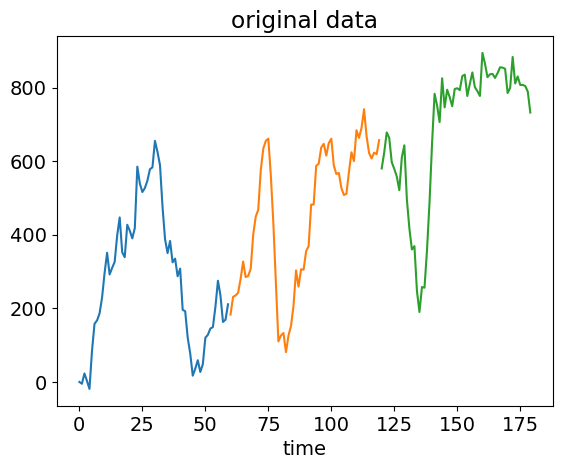

data:  10000


In [3]:
# ---> review "subtleties"?
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding (NB subtle)

### Split train-validation and rescale

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 2.919858910144656 0.22258218470654462 1.0
std_val average and mean: 2.8224247837554057 0.2727153579198286 1.0000000000000002


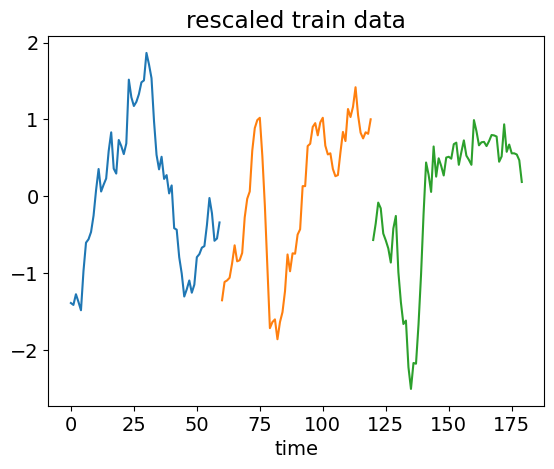

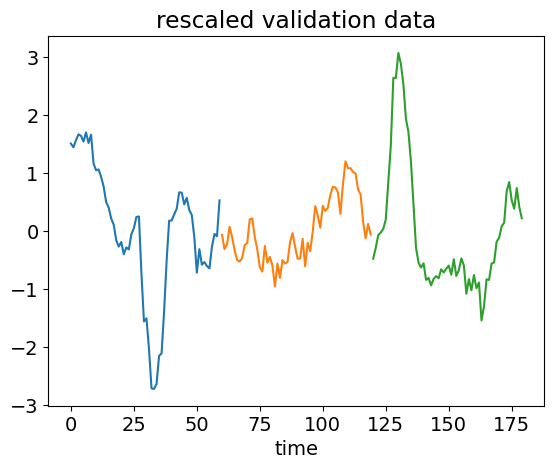

In [5]:
# ---> NB here validation is enough, no need for test set # ---> huh??
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

# ---> (two steps) rescaling:
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    # ---> NB to account for drift + varying jump length; to avoid "smoothing out" the pattern
    #      (would otherwise take more time to converge / get worse loss);
    #      ie must divide ALL samples by the same quantity # ---> review quickly?
for i in range(N_val):
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)

## Convolutional NN

In [6]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)
# ---> why "#" vs "##" ?

## from keras import regularizers, initializers

reg = tf.keras.regularizers.l2(0.2) ## raised to 0.2 the regularization strengths
#reg = regularizers.l1(0.1)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
NCONV = 1 #switch between 1 and 2 CNNs
NF = 5 #number of filters

# challenge: at most 600 tunable parameters
model = Sequential()
# 
if NCONV==1:
    # -----2-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, 
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
# 
if NCONV==2:
    # -----1-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg, ######## TRY WITHOUT ! (?)
                     activation='relu', input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Flatten())
    model.add(Dense(9, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(6, activation='relu'))
    model.add(Dropout(0.2))
    #model.add(Dense(10, activation='relu'))
    #model.add(Dropout(0.3))
model.add(Dense(n_class, activation='softmax')) # NB softmax !

print('----- Model',NCONV,'-----')
print(model.summary())

# optimizers
# .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
# .RMSprop()
# .Nadam()
opt = tf.keras.optimizers.Adam()

# compile the model
# categorical_crossentropy, 3 output nodes
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

# ---> TODO: count params?

C:\Users\Libero\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


----- Model 1 -----


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 50, 5)               │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling1d (AveragePooling1D) │ (None, 10, 5)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 4, 5)                │             180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 12)                  │             252 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              39 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
model.layers

[<Conv1D name=conv1d, built=True>,
 <AveragePooling1D name=average_pooling1d, built=True>,
 <Conv1D name=conv1d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

(11, 1, 5)
(5, 1, 11)


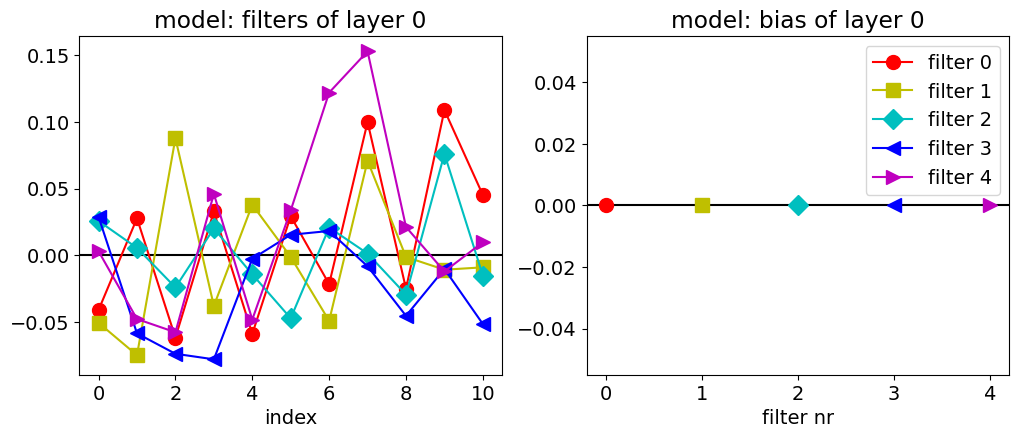

(7, 5, 5)
(5, 5, 7)


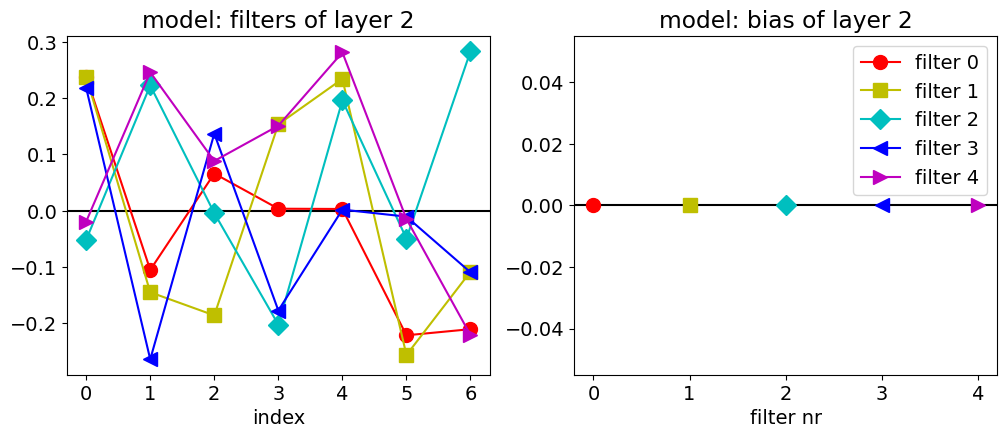

In [8]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
Show_weights(model,0)
Show_weights(model,2)

In [9]:
# ...LESSON ...
# Hyper-parameters
# NBwith small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 150

print('----- Model ',NCONV,'-----\nFITTING....')
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 

----- Model  1 -----
FITTING....
Epoch 1/150
40/40 - 3s - 74ms/step - accuracy: 0.3865 - loss: 1.1073 - val_accuracy: 0.4025 - val_loss: 1.0931
Epoch 2/150
40/40 - 0s - 8ms/step - accuracy: 0.4201 - loss: 1.0753 - val_accuracy: 0.4420 - val_loss: 1.0578
Epoch 3/150
40/40 - 0s - 7ms/step - accuracy: 0.4554 - loss: 1.0311 - val_accuracy: 0.4845 - val_loss: 1.0015
Epoch 4/150
40/40 - 0s - 7ms/step - accuracy: 0.5215 - loss: 0.9688 - val_accuracy: 0.5615 - val_loss: 0.9327
Epoch 5/150
40/40 - 0s - 7ms/step - accuracy: 0.5894 - loss: 0.9027 - val_accuracy: 0.6375 - val_loss: 0.8604
Epoch 6/150
40/40 - 0s - 7ms/step - accuracy: 0.6386 - loss: 0.8367 - val_accuracy: 0.6850 - val_loss: 0.7962
Epoch 7/150
40/40 - 0s - 7ms/step - accuracy: 0.6809 - loss: 0.7830 - val_accuracy: 0.7225 - val_loss: 0.7438
Epoch 8/150
40/40 - 0s - 7ms/step - accuracy: 0.7190 - loss: 0.7352 - val_accuracy: 0.7515 - val_loss: 0.6986
Epoch 9/150
40/40 - 0s - 7ms/step - accuracy: 0.7517 - loss: 0.6930 - val_accuracy: 0.

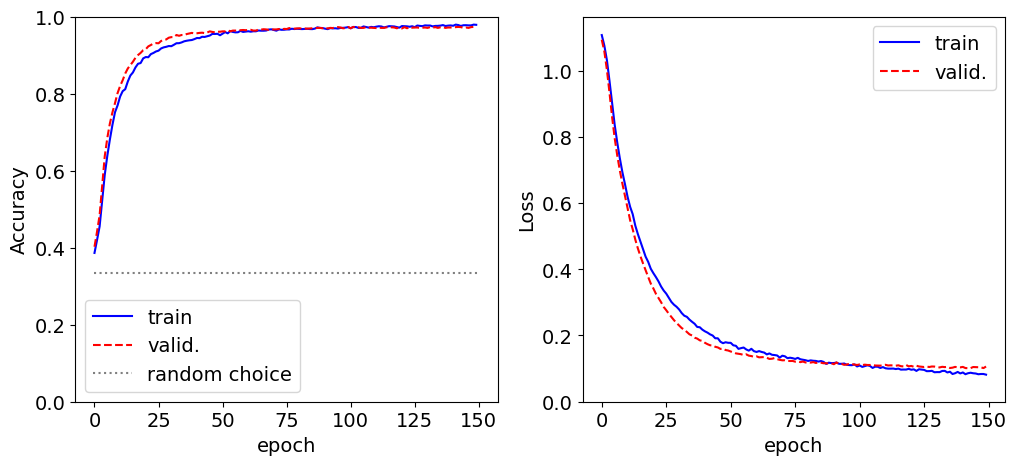

(11, 1, 5)
(5, 1, 11)


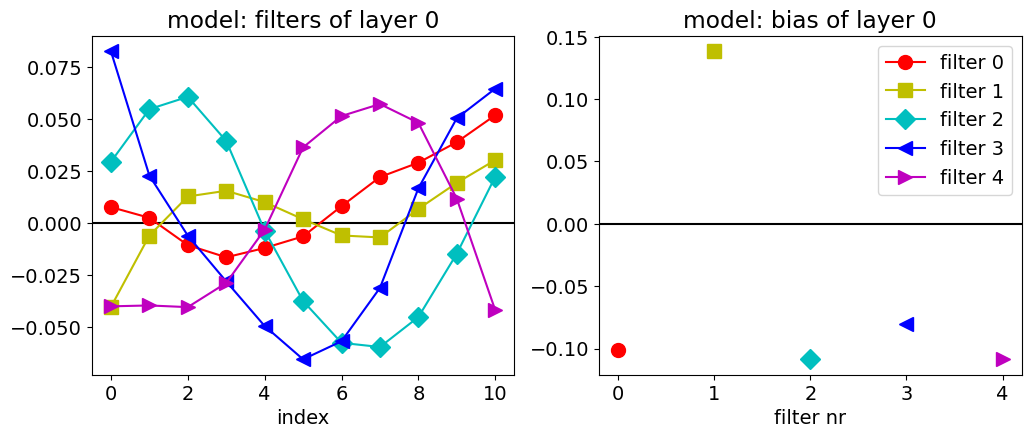

(7, 5, 5)
(5, 5, 7)


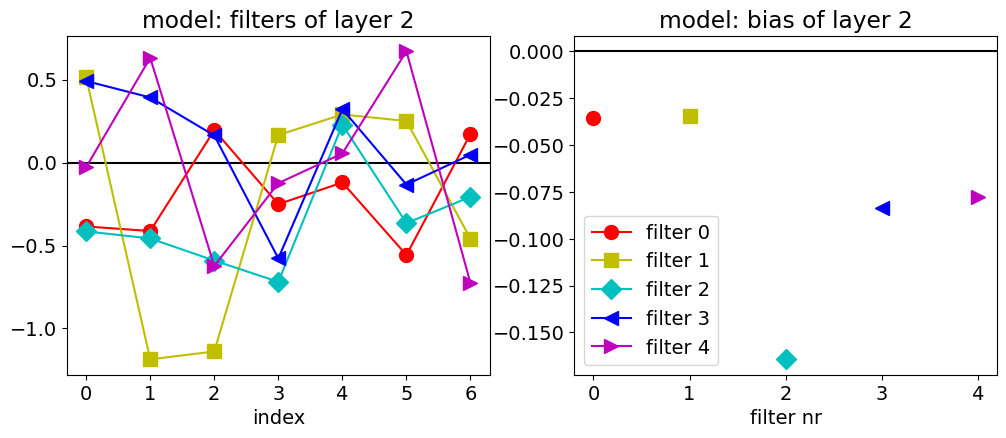

In [10]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
Show_history(fit)
Show_weights(model,0)
Show_weights(model,2)

In [11]:
# ...LESSON ...
reg2 = tf.keras.regularizers.l1(0.5)
model2 = keras.models.clone_model(model)
model2.layers[0].kernel_regularizer = reg2
model2.layers[2].kernel_regularizer = reg2
opt2 = tf.keras.optimizers.Adam()   # NEW optimizer instance
model2.compile(loss=keras.losses.categorical_crossentropy,optimizer=opt2,metrics=['accuracy'])

BATCH_SIZE2 = 200
EPOCHS2 = 150

fit2 = model2.fit(x_train,y_train,batch_size=BATCH_SIZE2,epochs=EPOCHS2,
                validation_data=(x_val, y_val), verbose=2, shuffle=True) 

# ---> NB diff regularizer but similar weights (smooth); also try out diff rescaling (sometimes some weights go to zero)

Epoch 1/150
40/40 - 3s - 64ms/step - accuracy: 0.3356 - loss: 1.1173 - val_accuracy: 0.3995 - val_loss: 1.1036
Epoch 2/150
40/40 - 0s - 8ms/step - accuracy: 0.3870 - loss: 1.0967 - val_accuracy: 0.4010 - val_loss: 1.0907
Epoch 3/150
40/40 - 0s - 7ms/step - accuracy: 0.4008 - loss: 1.0776 - val_accuracy: 0.4075 - val_loss: 1.0666
Epoch 4/150
40/40 - 0s - 7ms/step - accuracy: 0.4665 - loss: 1.0467 - val_accuracy: 0.5115 - val_loss: 1.0253
Epoch 5/150
40/40 - 0s - 7ms/step - accuracy: 0.5546 - loss: 0.9935 - val_accuracy: 0.6200 - val_loss: 0.9592
Epoch 6/150
40/40 - 0s - 7ms/step - accuracy: 0.6239 - loss: 0.9268 - val_accuracy: 0.6835 - val_loss: 0.8892
Epoch 7/150
40/40 - 0s - 7ms/step - accuracy: 0.6817 - loss: 0.8611 - val_accuracy: 0.7110 - val_loss: 0.8251
Epoch 8/150
40/40 - 0s - 7ms/step - accuracy: 0.7179 - loss: 0.8034 - val_accuracy: 0.7340 - val_loss: 0.7753
Epoch 9/150
40/40 - 0s - 7ms/step - accuracy: 0.7490 - loss: 0.7591 - val_accuracy: 0.7760 - val_loss: 0.7293
Epoch 10/

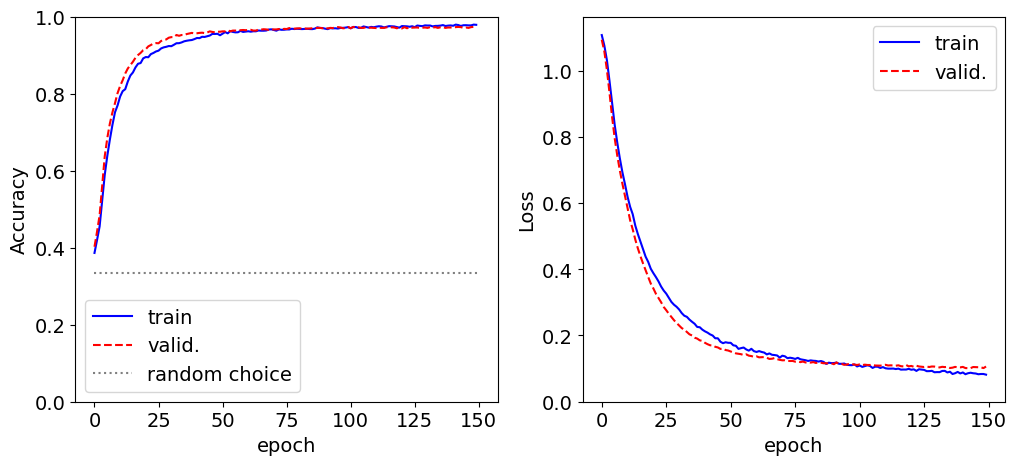

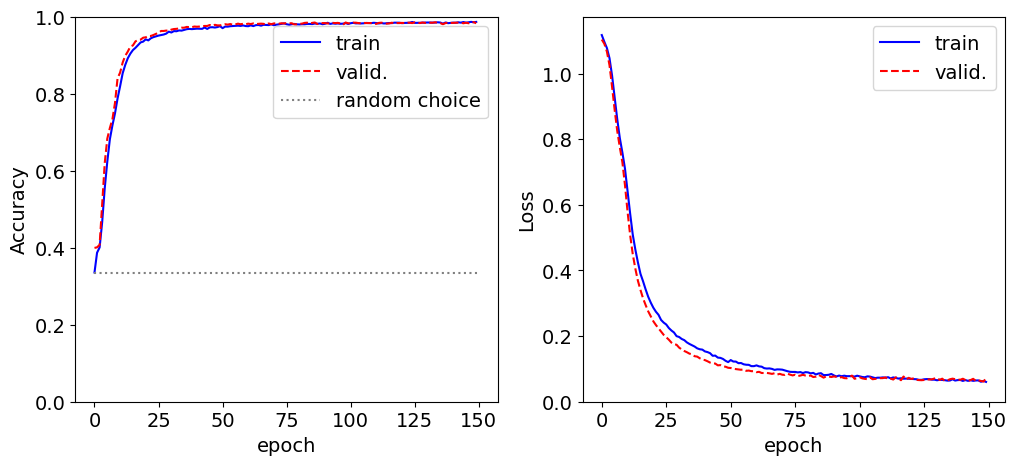

(11, 1, 5)
(5, 1, 11)


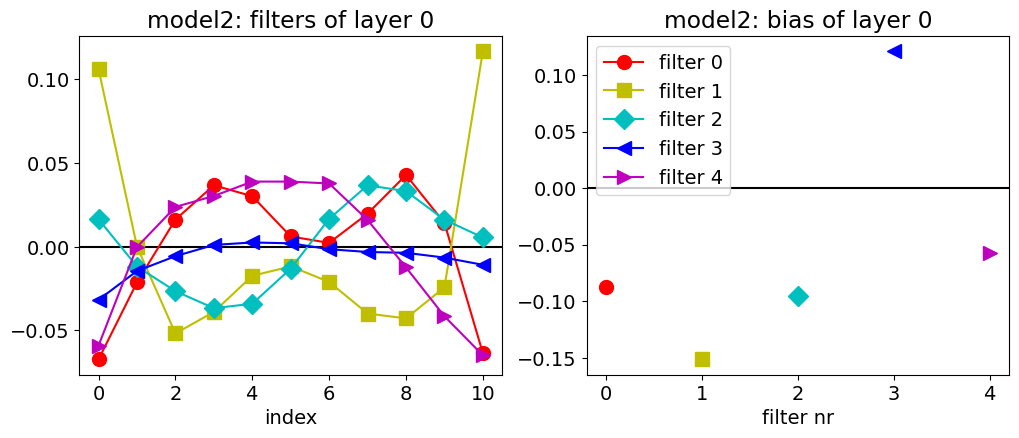

(7, 5, 5)
(5, 5, 7)


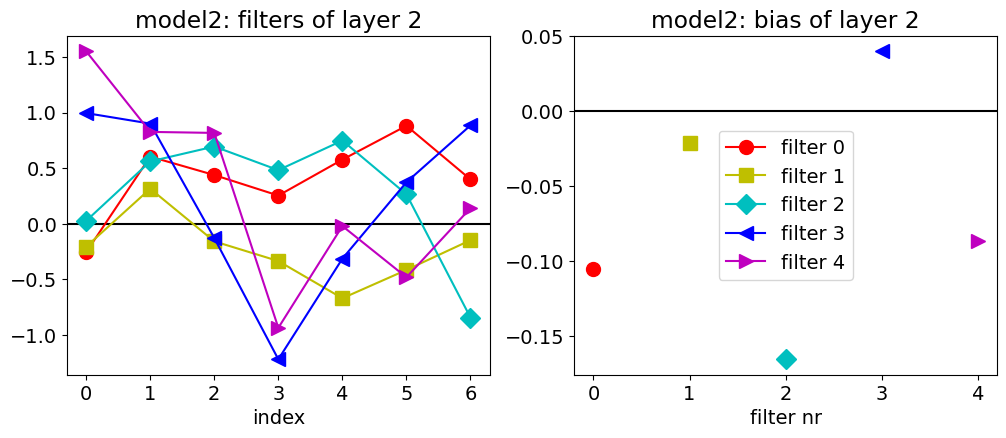

In [12]:
Show_history(fit)
Show_history(fit2)
Show_weights(model2,0,label="model2")
Show_weights(model2,2,label="model2")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


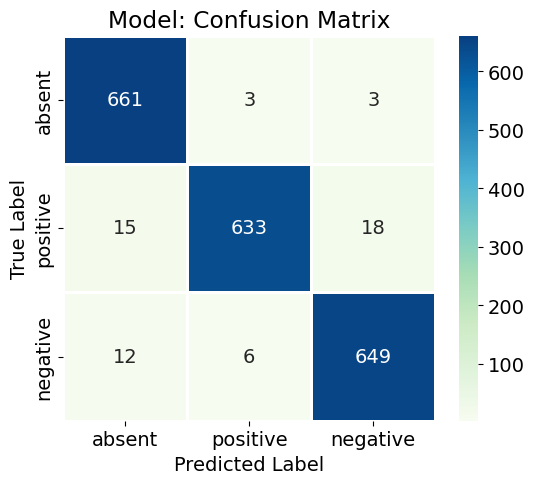

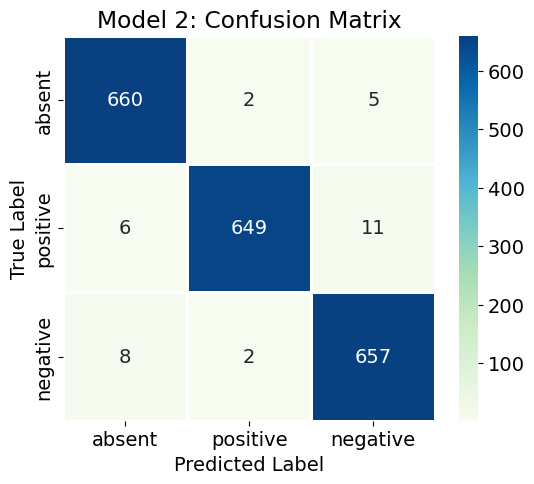

In [13]:
# confusion table: compare true labels with predicted ones
import pandas as pd
from scipy import stats

import seaborn 
from sklearn import metrics

from sklearn.metrics import classification_report
from sklearn import preprocessing

LABELS = ["absent","positive","negative"] # from labels y 
cmap="GnBu"

def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    seaborn.heatmap(matrix,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

y_pred_val = model.predict(x_val)
y_pred_val2 = model2.predict(x_val)
# Take the class with the highest probability from the val predictions
max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)
max_y_pred_val2 = np.argmax(y_pred_val2, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val)
show_confusion_matrix(max_y_val, max_y_pred_val2, label="Model 2")

#print(classification_report(max_y_val, max_y_pred_val))